<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
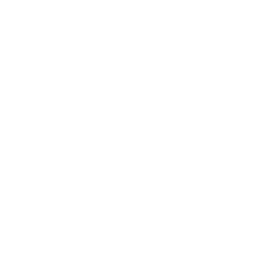
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Moleculaire subtypeclassificatie op basis van genexpressie</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Biotech / Genomische oncologie &nbsp;|&nbsp; maart 2026</p>
</div>
</div>
</div>

## Managementsamenvatting

Classificeer tumorbiopten in vier moleculaire subtypes (Luminal-A, Luminal-B, HER2-enriched, Basal-like) met behulp van genexpressie-biomarkerpanels. Pas canonieke discriminantanalyse toe om de hoogdimensionale expressieruimte te reduceren tot interpreteerbare variatie-assen. Gebruik MANOVA om te toetsen of de gemiddelde expressieprofielen significant verschillen tussen de subtypes. Kruisvalideer om de betrouwbaarheid van de classificatie te schatten voor klinische besluitvorming bij de keuze van het behandeltraject.

## Gegevensbronnen

| Bron | Beschrijving | Records |
|--------|-------------|--------|
| WORK.GENE_EXPR | Tumorgenexpressie met subtypelabels | 100 |
| WORK.NEW_BIOPSIES | Niet-geclassificeerde biopten | 100 |


---

In [1]:
/* --------------------------------------------------------
   Genereer een synthetische genexpressie-dataset
   met vier moleculaire subtypes
   -------------------------------------------------------- */
GEGEVENS work.gene_expr;
    CALL streaminit(42);
    LENGTE mol_subtype $12;
    REEKS subtype_list[4] $12 _temporary_ ('LUMINAL_A' 'LUMINAL_B' 'HER2_ENRICH' 'BASAL_LIKE');
    DOE sample_id = 1 TOT 100;
        tumor_id = cat('TUM-', SCHRIJVEN(sample_id, z5.));
        sub_idx = int(rand('uniform') * 4) + 1;
        mol_subtype = subtype_list[sub_idx];

        /* Gesimuleerde genexpressie-markers (log2-schaal) */
        SELECTEREN (mol_subtype);
            WANNEER ('LUMINAL_A') DOE;
                esr1_expr = round(rand('normal', 11.5, 1.2), 0.01);
                pgr_expr = round(rand('normal', 9.8, 1.5), 0.01);
                erbb2_expr = round(rand('normal', 7.2, 0.9), 0.01);
                ki67_expr = round(rand('normal', 6.0, 1.0), 0.01);
                egfr_expr = round(rand('normal', 6.5, 1.1), 0.01);
                cytokeratin5 = round(rand('normal', 5.0, 0.8), 0.01);
                tp53_mut_load = round(rand('poisson', 1.5), 1);
                prolif_score = round(rand('normal', 3.2, 0.8), 0.01);
            EINDE;
            WANNEER ('LUMINAL_B') DOE;
                esr1_expr = round(rand('normal', 10.0, 1.4), 0.01);
                pgr_expr = round(rand('normal', 7.5, 1.8), 0.01);
                erbb2_expr = round(rand('normal', 8.5, 1.2), 0.01);
                ki67_expr = round(rand('normal', 8.5, 1.2), 0.01);
                egfr_expr = round(rand('normal', 7.0, 1.0), 0.01);
                cytokeratin5 = round(rand('normal', 5.5, 0.9), 0.01);
                tp53_mut_load = round(rand('poisson', 3.0), 1);
                prolif_score = round(rand('normal', 6.0, 1.0), 0.01);
            EINDE;
            WANNEER ('HER2_ENRICH') DOE;
                esr1_expr = round(rand('normal', 6.5, 1.5), 0.01);
                pgr_expr = round(rand('normal', 5.0, 1.2), 0.01);
                erbb2_expr = round(rand('normal', 13.0, 1.0), 0.01);
                ki67_expr = round(rand('normal', 9.0, 1.3), 0.01);
                egfr_expr = round(rand('normal', 8.5, 1.2), 0.01);
                cytokeratin5 = round(rand('normal', 6.0, 1.0), 0.01);
                tp53_mut_load = round(rand('poisson', 5.0), 1);
                prolif_score = round(rand('normal', 7.5, 1.1), 0.01);
            EINDE;
            WANNEER ('BASAL_LIKE') DOE;
                esr1_expr = round(rand('normal', 4.5, 1.3), 0.01);
                pgr_expr = round(rand('normal', 3.8, 1.0), 0.01);
                erbb2_expr = round(rand('normal', 6.0, 1.1), 0.01);
                ki67_expr = round(rand('normal', 10.5, 1.4), 0.01);
                egfr_expr = round(rand('normal', 11.0, 1.3), 0.01);
                cytokeratin5 = round(rand('normal', 10.5, 1.2), 0.01);
                tp53_mut_load = round(rand('poisson', 7.0), 1);
                prolif_score = round(rand('normal', 8.8, 1.2), 0.01);
            EINDE;
            ANDERS_WEL;
        EINDE;
        UITVOER;
    EINDE;
    VERWIJDEREN sub_idx;
UITVOEREN;


NOTE: DATA work.gene_expr


NOTE: Wrote work.gene_expr (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


In [2]:
/* --------------------------------------------------------
   Genereer niet-geclassificeerde biopsiemonsters
   -------------------------------------------------------- */
GEGEVENS work.new_biopsies;
    CALL streaminit(55);
    DOE sample_id = 5001 TOT 5100;
        tumor_id = cat('TUM-', SCHRIJVEN(sample_id, z5.));
        esr1_expr = round(rand('normal', 8.0, 3.0), 0.01);
        pgr_expr = round(rand('normal', 6.5, 3.0), 0.01);
        erbb2_expr = round(rand('normal', 8.5, 2.5), 0.01);
        ki67_expr = round(rand('normal', 8.0, 2.0), 0.01);
        egfr_expr = round(rand('normal', 8.0, 2.0), 0.01);
        cytokeratin5 = round(rand('normal', 7.0, 2.5), 0.01);
        tp53_mut_load = round(rand('poisson', 4.0), 1);
        prolif_score = round(rand('normal', 6.0, 2.5), 0.01);
        mol_subtype = '';
        UITVOER;
    EINDE;
UITVOEREN;


NOTE: DATA work.new_biopsies


NOTE: Wrote work.new_biopsies (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


---

                                           Verdeling van moleculaire subtypes                                           

                                                   The FREQ Procedure

Moleculair subtype    Frequency    Percent
-------------------------------------------
BASAL_LIKE                   24     24.00
HER2_ENRICH                  22     22.00
LUMINAL_A                    25     25.00
LUMINAL_B                    29     29.00
                                    Samenvatting genexpressie per moleculair subtype                                    

                                                  The MEANS Procedure

                                  Analysis Variable : esr1_expr ESR1-expressie (log2)

        Moleculair subtype          N Obs           Mean        Std Dev
        ---------------------------------------------------------------
        BASAL_LIKE                     24      4.5479167      1.2257100
        HER2_ENRICH                    22      7.1318182


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mol_subtype.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


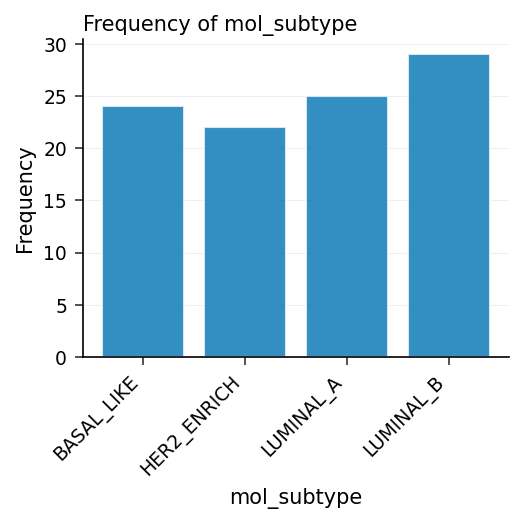

In [3]:
/* --------------------------------------------------------
   Basisverdeling van subtypes en expressieprofielen
   -------------------------------------------------------- */
PROCEDURE FREQUENTIES GEGEVENS=work.gene_expr;
    TABLES mol_subtype / nocum;
    LABEL mol_subtype='Moleculair subtype';
    TITEL 'Verdeling van moleculaire subtypes';
UITVOEREN;

PROCEDURE GEMIDDELDEN GEGEVENS=work.gene_expr n mean std;
    KLASSE mol_subtype;
    VARIABELE esr1_expr pgr_expr erbb2_expr ki67_expr egfr_expr
        cytokeratin5 tp53_mut_load prolif_score;
    LABEL mol_subtype='Moleculair subtype'
          esr1_expr='ESR1-expressie (log2)'
          pgr_expr='PGR-expressie (log2)'
          erbb2_expr='ERBB2-expressie (log2)'
          ki67_expr='Ki-67-expressie (log2)'
          egfr_expr='EGFR-expressie (log2)'
          cytokeratin5='Cytokeratine-5-expressie (log2)'
          tp53_mut_load='TP53-mutatielast'
          prolif_score='Proliferatiescore';
    TITEL 'Samenvatting genexpressie per moleculair subtype';
UITVOEREN;


---

In [4]:
/* --------------------------------------------------------
   Canonieke discriminantanalyse met MANOVA
   CANONICAL extraheert discriminant-assen voor visualisatie.
   MANOVA toetst de algehele scheiding van gemiddelden tussen subtypes.
   -------------------------------------------------------- */
PROCEDURE DISCRIM GEGEVENS=work.gene_expr
        METHOD=NORMAL
        pool=TEST
        canonical
        MANOVA
        crossvalidate
        out=work.subtype_canonical
        OUTSTAT=work.subtype_stats;
    KLASSE mol_subtype;
    VARIABELE esr1_expr pgr_expr erbb2_expr ki67_expr egfr_expr
        cytokeratin5 tp53_mut_load prolif_score;
    PRIORS equal;
    LABEL mol_subtype='Moleculair subtype'
          esr1_expr='ESR1-expressie (log2)'
          pgr_expr='PGR-expressie (log2)'
          erbb2_expr='ERBB2-expressie (log2)'
          ki67_expr='Ki-67-expressie (log2)'
          egfr_expr='EGFR-expressie (log2)'
          cytokeratin5='Cytokeratine-5-expressie (log2)'
          tp53_mut_load='TP53-mutatielast'
          prolif_score='Proliferatiescore';
    TITEL 'Canonieke discriminantanalyse: moleculaire tumorsubtypes';
    title2 'MANOVA-toets van verschillen in gemiddelde expressieprofielen';
UITVOEREN;


                                    Samenvatting genexpressie per moleculair subtype                                    


                          The DISCRIM Procedure

      Total Sample Size         100    DF Total              99
      Variables                   8    DF Within Classes     96
      Classes                     4

                        Prior Probabilities for Classification

                      BASAL_LIKE HER2_ENRICH   LUMINAL_A   LUMINAL_B

     Prior                0.2400      0.2200      0.2500      0.2900
     Frequency                24          22          25          29

                      Class Level Information for Discriminant Analysis

      BASAL_LIKE: 4.5479  3.9108  5.9921  10.3504  11.0979  10.6942  7.5833  8.9167
      HER2_ENRICH: 7.1318  4.9155  12.7623  8.5077  8.1259  5.7295  5.0000  7.5882
      LUMINAL_A: 11.0964  9.6360  7.3532  6.2492  6.1496  4.8280  1.4800  3.1664
      LUMINAL_B: 9.8003  6.9972  8.5069  8.5469  6.6797  5.3259  2.79


NOTE: PROC DISCRIM data=work.gene_expr method=Normal pool=Test

NOTE: Using Python sklearn version 1.8.0 for discriminant analysis
NOTE: Class Frequencies:
NOTE:   BASAL_LIKE: 24
NOTE:   HER2_ENRICH: 22
NOTE:   LUMINAL_A: 25
NOTE:   LUMINAL_B: 29
NOTE: Class Means:
NOTE:   BASAL_LIKE: 4.5479, 3.9108, 5.9921, 10.3504, 11.0979, 10.6942, 7.5833, 8.9167
NOTE:   HER2_ENRICH: 7.1318, 4.9155, 12.7623, 8.5077, 8.1259, 5.7295, 5.0000, 7.5882
NOTE:   LUMINAL_A: 11.0964, 9.6360, 7.3532, 6.2492, 6.1496, 4.8280, 1.4800, 3.1664
NOTE:   LUMINAL_B: 9.8003, 6.9972, 8.5069, 8.5469, 6.6797, 5.3259, 2.7931, 6.0307
NOTE: Resubstitution Error Rate: 0.0000
NOTE: Cross-Validation Error Rate: 0.0400
NOTE: Confusion Matrix:
NOTE:     24    0    0    0
NOTE:      0   22    0    0
NOTE:      0    0   25    0
NOTE:      0    0    0   29
NOTE: Multivariate Statistics:
NOTE:   Wilks' Lambda: 0.0037 (p = 0.000000)
NOTE: PROC DISCRIM: 100 observations, 8 variables, method=Normal, pool=Test


---

                                    Samenvatting genexpressie per moleculair subtype                                    




NOTE: PROC SGPLOT data=work.subtype_canonical

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


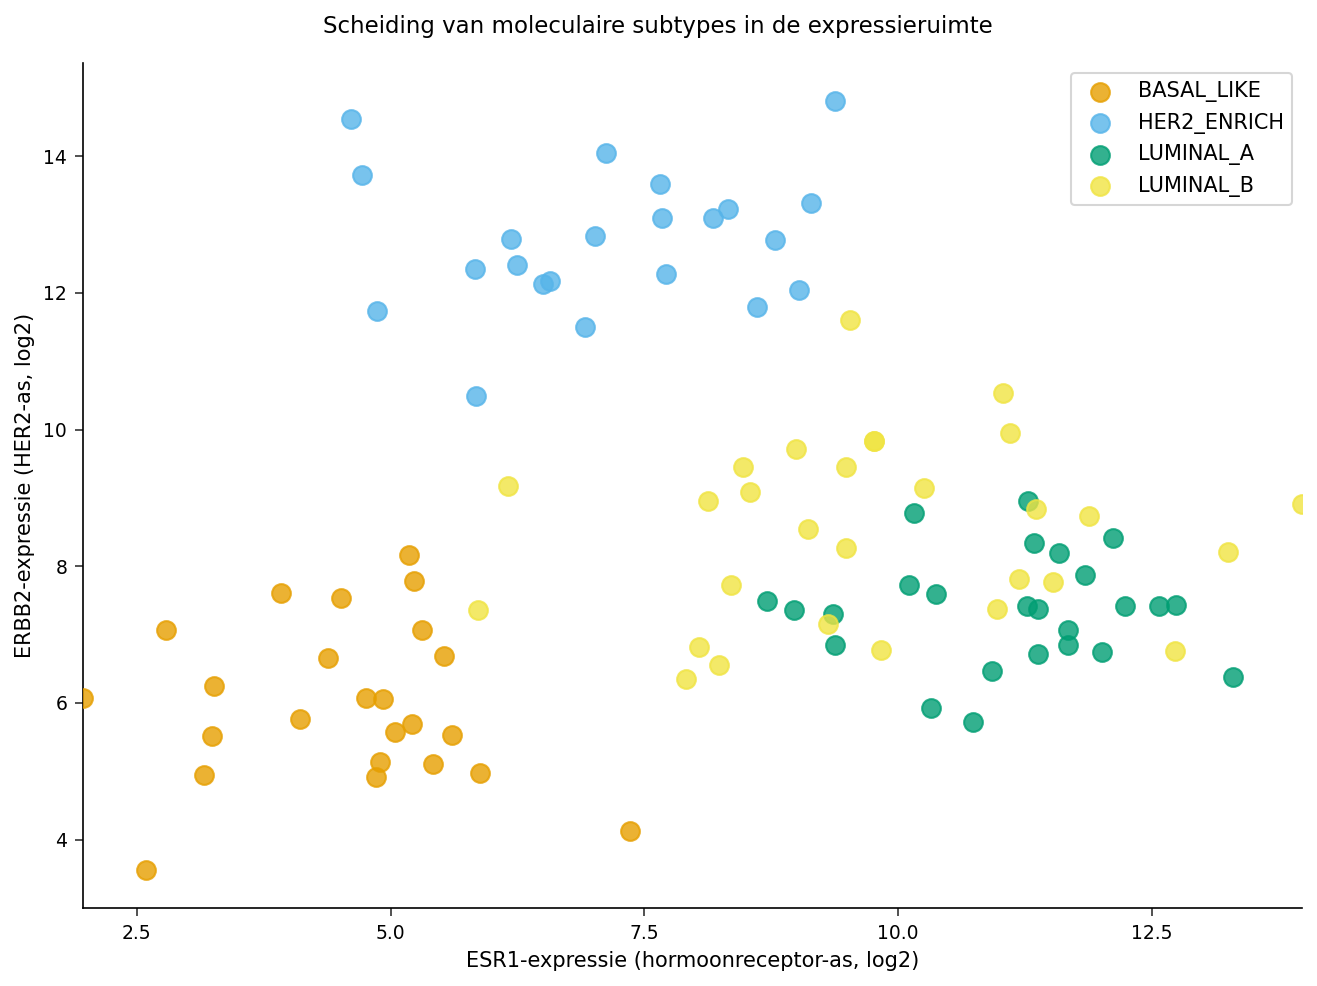

In [5]:
/* --------------------------------------------------------
   Scheiding van subtypes in de expressieruimte
   ESR1 (hormoonreceptor-as) versus ERBB2 (HER2-as),
   afkomstig uit de discriminant-dataset OUT=.
   -------------------------------------------------------- */
PROCEDURE SGPLOT GEGEVENS=work.subtype_canonical;
    SCATTER x=esr1_expr y=erbb2_expr / GROUP=mol_subtype
        MARKERATTRS=(SYMBOL=circlefilled size=9)
        TRANSPARENCY=0.2;
    XAXIS label='ESR1-expressie (hormoonreceptor-as, log2)';
    YAXIS label='ERBB2-expressie (HER2-as, log2)';
    TITEL 'Scheiding van moleculaire subtypes in de expressieruimte';
UITVOEREN;



In [6]:
/* --------------------------------------------------------
   Classificeer ongetypeerde biopsiemonsters
   -------------------------------------------------------- */
PROCEDURE DISCRIM GEGEVENS=work.gene_expr
        testdata=work.new_biopsies
        testout=work.classified_biopsies
        METHOD=NORMAL
        pool=TEST
        canonical;
    KLASSE mol_subtype;
    VARIABELE esr1_expr pgr_expr erbb2_expr ki67_expr egfr_expr
        cytokeratin5 tp53_mut_load prolif_score;
    PRIORS equal;
    LABEL mol_subtype='Moleculair subtype'
          esr1_expr='ESR1-expressie (log2)'
          pgr_expr='PGR-expressie (log2)'
          erbb2_expr='ERBB2-expressie (log2)'
          ki67_expr='Ki-67-expressie (log2)'
          egfr_expr='EGFR-expressie (log2)'
          cytokeratin5='Cytokeratine-5-expressie (log2)'
          tp53_mut_load='TP53-mutatielast'
          prolif_score='Proliferatiescore';
    TITEL 'Classificatie van moleculaire subtypes voor nieuwe biopten';
UITVOEREN;


                                    Samenvatting genexpressie per moleculair subtype                                    


                          The DISCRIM Procedure

      Total Sample Size         100    DF Total              99
      Variables                   8    DF Within Classes     96
      Classes                     4

                        Prior Probabilities for Classification

                      BASAL_LIKE HER2_ENRICH   LUMINAL_A   LUMINAL_B

     Prior                0.2400      0.2200      0.2500      0.2900
     Frequency                24          22          25          29

                      Class Level Information for Discriminant Analysis

      BASAL_LIKE: 4.5479  3.9108  5.9921  10.3504  11.0979  10.6942  7.5833  8.9167
      HER2_ENRICH: 7.1318  4.9155  12.7623  8.5077  8.1259  5.7295  5.0000  7.5882
      LUMINAL_A: 11.0964  9.6360  7.3532  6.2492  6.1496  4.8280  1.4800  3.1664
      LUMINAL_B: 9.8003  6.9972  8.5069  8.5469  6.6797  5.3259  2.79


NOTE: PROC DISCRIM data=work.gene_expr method=Normal pool=Test

NOTE: Using Python sklearn version 1.8.0 for discriminant analysis
NOTE: Class Frequencies:
NOTE:   BASAL_LIKE: 24
NOTE:   HER2_ENRICH: 22
NOTE:   LUMINAL_A: 25
NOTE:   LUMINAL_B: 29
NOTE: Class Means:
NOTE:   BASAL_LIKE: 4.5479, 3.9108, 5.9921, 10.3504, 11.0979, 10.6942, 7.5833, 8.9167
NOTE:   HER2_ENRICH: 7.1318, 4.9155, 12.7623, 8.5077, 8.1259, 5.7295, 5.0000, 7.5882
NOTE:   LUMINAL_A: 11.0964, 9.6360, 7.3532, 6.2492, 6.1496, 4.8280, 1.4800, 3.1664
NOTE:   LUMINAL_B: 9.8003, 6.9972, 8.5069, 8.5469, 6.6797, 5.3259, 2.7931, 6.0307
NOTE: Resubstitution Error Rate: 0.0000
NOTE: Confusion Matrix:
NOTE:     24    0    0    0
NOTE:      0   22    0    0
NOTE:      0    0   25    0
NOTE:      0    0    0   29
NOTE: PROC DISCRIM: 100 observations, 8 variables, method=Normal, pool=Test


                             Voorspelde verdeling van moleculaire subtypes: nieuwe biopten                              

                                                   The FREQ Procedure

_INTO_         Frequency    Percent
------------------------------------
BASAL_LIKE             7      7.00
HER2_ENRICH           47     47.00
LUMINAL_A             10     10.00
LUMINAL_B             36     36.00



NOTE: PROC FREQ
NOTE: ODS plot written: freq__into_.spec.json
NOTE: PROC FREQ statement used.


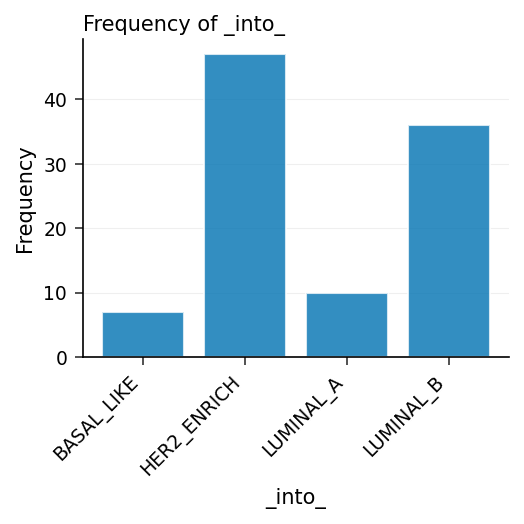

In [7]:
/* --------------------------------------------------------
   Classificatieverdeling voor nieuwe biopten
   -------------------------------------------------------- */
PROCEDURE FREQUENTIES GEGEVENS=work.classified_biopsies;
    TABLES _into_ / nocum;
    TITEL 'Voorspelde verdeling van moleculaire subtypes: nieuwe biopten';
UITVOEREN;


---

### Interpretatie

De MANOVA-toets bevestigt een zeer significant verschil in gemiddelde genexpressieprofielen tussen de vier moleculaire subtypes: Wilks' Lambda = 0.0037 met p < 0.0001, dus de subtypes bezetten duidelijk onderscheiden gebieden van de expressieruimte met acht markers. Die scheiding is zichtbaar in de spreidingsplot van de expressieruimte, waar Luminal-tumoren hoog op de ESR1-as (hormoonreceptor) liggen, terwijl HER2-enriched-tumoren naar de top van de ERBB2-as opschuiven en Basal-like-tumoren linksonder in beide vallen. Resubstitutieclassificatie van de 100 gelabelde tumoren is perfect (0% schijnbare fout), en leave-one-out-kruisvalidatie legt het foutpercentage op slechts 4% — een eerlijke kruisgevalideerde nauwkeurigheid van 96%, waarbij elk subtype correct wordt teruggevonden in de kruisgevalideerde verwarringsmatrix. Het toepassen van de getrainde classifier op de 100 ongelabelde biopten wijst er 47 toe aan HER2-enriched, 36 aan Luminal-B, 10 aan Luminal-A en 7 aan Basal-like; de neiging naar HER2-enriched weerspiegelt de verhoogde ERBB2- en proliferatiewaarden van het biopsiepanel. Deze subtypebepalingen sturen de keuze van het behandeltraject: endocriene therapie voor Luminal-tumoren, gerichte anti-HER2-middelen voor de HER2-enriched-groep en chemotherapieschema's voor Basal-like-tumoren.


---

In [8]:
/* --------------------------------------------------------
   Exporteer geclassificeerde biopten voor behandelplanning
   -------------------------------------------------------- */
PROCEDURE EXPORTEREN GEGEVENS=work.classified_biopsies
    OUTFILE='classified_biopsy_subtypes.csv'
    DBMS=csv REPLACE;
UITVOEREN;

PROCEDURE EXPORTEREN GEGEVENS=work.subtype_canonical
    OUTFILE='canonical_subtype_scores.csv'
    DBMS=csv REPLACE;
UITVOEREN;



NOTE: PROC EXPORT data=work.classified_biopsies outfile=classified_biopsy_subtypes.csv

NOTE: Exported 100 rows to classified_biopsy_subtypes.csv.
NOTE: PROC EXPORT data=work.subtype_canonical outfile=canonical_subtype_scores.csv

NOTE: Exported 100 rows to canonical_subtype_scores.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Vertrouwelijk
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Mogelijk gemaakt door <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>